Productivty:

In [201]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from time import time
import matplotlib.pyplot as plt
from main_semi_sticky_wages_data import ModelClass
from plots import plot_shares, plot_series
from helper_functions import params_to_latex


model = ModelClass()

par = model.par
sim = model.sim

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


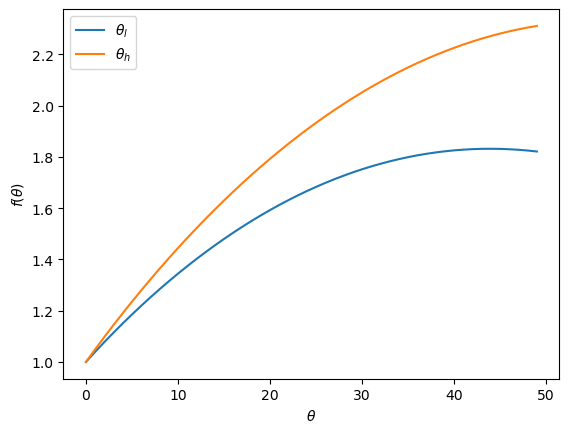

In [202]:
theta_l =  1 + 0.04*np.arange(par.n) - 0.0007*np.arange(par.n)**(1.9)

theta_h =  1.0 + 0.05*np.arange(par.n) - 0.0007*np.arange(par.n)**(1.9)

# Save theta values for later use
np.savetxt('Exogenous_estimation/theta_l.csv', theta_l, delimiter=',')
np.savetxt('Exogenous_estimation/theta_h.csv', theta_h, delimiter=',')

plt.plot(theta_l, label=r'$\theta_l$')
plt.plot(theta_h, label=r'$\theta_h$')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$f(\theta)$')
plt.legend()
plt.show()

Retirement (test)

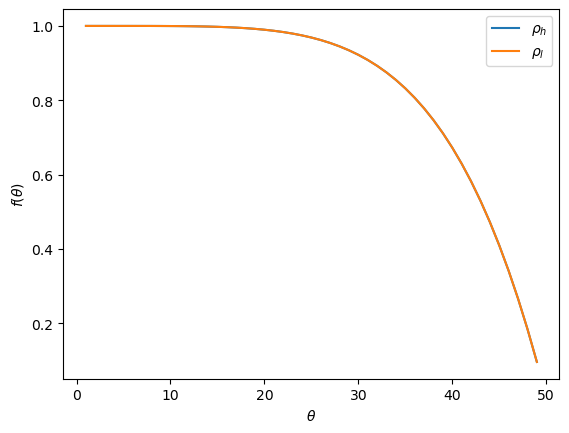

In [203]:
x = np.linspace(1.0, par.n - 1, par.n - 1)
rho_h_shape = 5.0
rho_h = -((x / par.n) ** rho_h_shape) + 1

rho_l_shape = 5.0
rho_l = -((x / par.n) ** rho_l_shape) + 1

# Save rho values for later use
np.savetxt('Exogenous_estimation/rho_h.csv', rho_h, delimiter=',')
np.savetxt('Exogenous_estimation/rho_l.csv', rho_l, delimiter=',')

plt.plot(x, rho_h, label=r'$\rho_h$')
plt.plot(x, rho_l, label=r'$\rho_l$')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$f(\theta)$')
plt.legend()

Retirement (data)

In [204]:
transition_matrix

,n_obs1990,n_obs1991,n_obs1992,n_obs1993,n_obs1994,n_obs1995,n_obs1996,n_obs1997,n_obs1998,n_obs1999,...,survival_rate2013,survival_rate2014,survival_rate2015,survival_rate2016,survival_rate2017,survival_rate2018,survival_rate2019,survival_rate2020,survival_rate2021,survival_rate2022
age,,,,,,,,,,,,,,,,,,,,,
25,53699,54164,49630,44758,44099,44720,46935,47684,45740,44402,...,1.174938,1.202703,1.184508,1.219165,1.210854,1.181830,1.199035,1.282232,1.238243,1.201715
26,54075,54334,55766,51576,48865,47290,46923,50319,51262,48143,...,1.142509,1.167734,1.150514,1.170688,1.164934,1.139665,1.141364,1.197650,1.163354,1.131020
27,54932,54461,55966,57686,55416,51542,49384,50257,53922,53975,...,1.106284,1.115131,1.099821,1.123977,1.119637,1.088248,1.084900,1.131801,1.112105,1.075992
28,53221,54931,55759,57488,60944,57789,53670,52254,53226,55824,...,1.067033,1.077899,1.063827,1.090131,1.088762,1.060324,1.056034,1.094125,1.071427,1.040810
29,52369,53199,55855,56773,59855,62994,59535,55884,54788,54503,...,1.040823,1.054213,1.041863,1.062979,1.054028,1.032315,1.037148,1.069570,1.045046,1.022425
30,52571,52031,53810,56677,58796,61537,64223,61617,57989,55704,...,1.036691,1.043477,1.031088,1.046870,1.042737,1.024556,1.027823,1.054917,1.044390,1.019045
31,51364,52281,52449,54488,58572,60262,62700,65963,63523,58573,...,1.016555,1.034640,1.021800,1.034837,1.036612,1.012565,1.020980,1.047087,1.035951,1.014506
32,51400,51021,52717,52987,56015,59591,61018,64369,67948,63887,...,1.017651,1.032233,1.014831,1.032284,1.031485,1.010757,1.015293,1.042298,1.027674,1.008488
33,51177,50966,51351,53102,54385,56810,60456,62427,65839,68434,...,1.016511,1.023041,1.009898,1.027232,1.023617,1.012069,1.013749,1.038560,1.024806,1.009879


In [205]:
transition_matrix = pd.read_csv('Data/transition_matrix_all.csv', header=0, index_col=0)

survival_rates = transition_matrix.loc[:, transition_matrix.columns.str.startswith('survival_rate')]
survival_rates = survival_rates.values
survival_rates = survival_rates[:-1, :]
# survival_rates = np.vstack([survival_rates.values, np.zeros((1, survival_rates.shape[1]))])

np.savetxt('Exogenous_estimation/survival_rates.csv', survival_rates, delimiter=',')


ss_distribution = transition_matrix.loc[:, "n_obs1990"]
ss_distribution = ss_distribution.values

ss_transition = ss_distribution[1:] / ss_distribution[:-1]

np.savetxt('Exogenous_estimation/ss_transition.csv', ss_transition, delimiter=',')
np.savetxt('Exogenous_estimation/ss_distribution.csv', ss_distribution, delimiter=',')


all_distribution = pd.read_csv('Data/transition_matrix_all.csv', header=0, index_col=0)
all_distribution = all_distribution.loc[:, all_distribution.columns.str.startswith('n_obs')]

youngest_distribution = all_distribution.iloc[0, :].values
youngest_distribution = youngest_distribution / youngest_distribution[0]

np.savetxt('Exogenous_estimation/youngest_distribution.csv', youngest_distribution, delimiter=',')

In [206]:
for index, i in enumerate(survival_rates):
    print(f"Index: {index}, Value: {i}")

Index: 0, Value: [1.0118252 1.0295769 1.0392102 1.0917602 1.0723599 1.049262  1.0720997
 1.0750357 1.0525361 1.0619341 1.0633159 1.041482  1.0506068 1.1010582
 1.1297133 1.1416134 1.1352564 0.9591254 1.0237135 1.0937549 1.1125866
 1.1247848 1.153219  1.1749376 1.2027032 1.184508  1.219165  1.2108544
 1.1818298 1.1990352 1.2822322 1.2382431 1.2017146]
Index: 1, Value: [1.0071383  1.0300364  1.0344296  1.0744532  1.0547836  1.0442799
 1.0710526  1.0716032  1.0529242  1.0540681  1.054441   1.0395619
 1.049847   1.0783043  1.108155   1.1176252  1.1049283  0.93857521
 1.0218781  1.0854748  1.0929352  1.1078836  1.1177944  1.1425089
 1.1677341  1.1505139  1.170688   1.1649343  1.1396652  1.1413636
 1.19765    1.1633538  1.1310204 ]
Index: 2, Value: [0.99998182 1.0238335  1.0271951  1.0564781  1.0428215  1.0412867
 1.058116   1.0590763  1.0352732  1.0414265  1.0431758  1.0270319
 1.034072   1.0731902  1.0881305  1.0993758  1.0866312  0.92317212
 1.0101668  1.0649729  1.0741389  1.0690101  1.0

In [207]:
for index, i in enumerate(ss_transition):
    print(f"Index: {index}, Value: {i}")

Index: 0, Value: 1.0070019925883165
Index: 1, Value: 1.0158483587609801
Index: 2, Value: 0.9688523993300808
Index: 3, Value: 0.9839912816369478
Index: 4, Value: 1.0038572437892646
Index: 5, Value: 0.977040573700329
Index: 6, Value: 1.00070087999377
Index: 7, Value: 0.9956614785992218
Index: 8, Value: 1.0110596557047111
Index: 9, Value: 0.9773689194673676
Index: 10, Value: 0.9865142766748398
Index: 11, Value: 1.0100621367007416
Index: 12, Value: 0.9677925067471027
Index: 13, Value: 0.9805614222149316
Index: 14, Value: 1.0298195353505781
Index: 15, Value: 0.992507157796414
Index: 16, Value: 1.046155734686362
Index: 17, Value: 1.0566941760863613
Index: 18, Value: 1.0273906686654453
Index: 19, Value: 0.959721146398141
Index: 20, Value: 0.9329917225068979
Index: 21, Value: 0.9083026535498019
Index: 22, Value: 0.9197767392411792
Index: 23, Value: 0.875526765718689
Index: 24, Value: 0.9588811265746191
Index: 25, Value: 0.9425752230158048
Index: 26, Value: 0.9690514591765315
Index: 27, Value: 

In [208]:
ss_transition.shape

(49,)

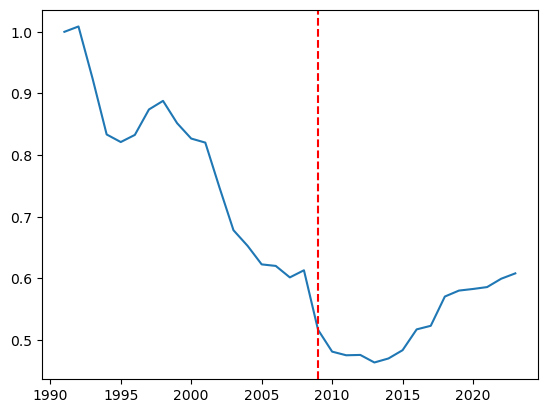

In [209]:


x = np.arange(1991, 2024)
plt.plot(x, youngest_distribution)
plt.axvline(x=2009, color='red', linestyle='--')

Produktivity (test)

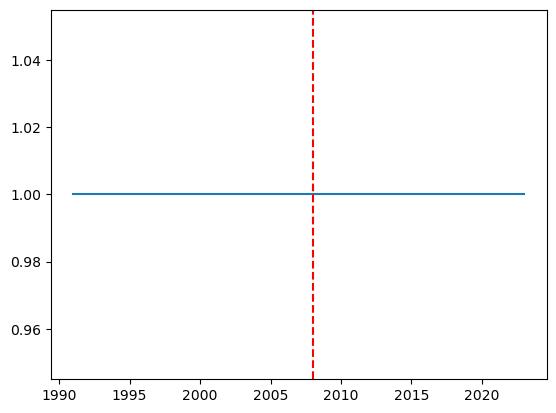

In [210]:
T = survival_rates.shape[1]

A = np.ones(T)
A[18] = 1.0

# np.savetxt('Exogenous_estimation/A.csv', A, delimiter=',')

plt.plot(x, A)
plt.axvline(x=2008, color='red', linestyle='--')

Produktivity (data)

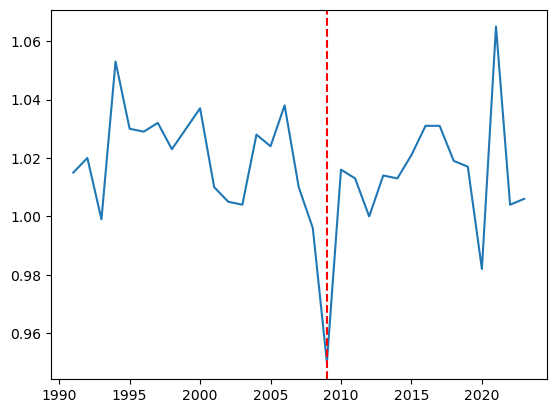

In [211]:
T = survival_rates.shape[1]

gdp_data = pd.read_csv('Data/gdp.csv', header=0)

A = gdp_data.values[0]
A = A[1::]
A = np.ones(T) + A / 100

np.savetxt('Exogenous_estimation/A.csv', A, delimiter=',')

plt.plot(x, A)
plt.axvline(x=2009, color='red', linestyle='--')

Moment to match (test)

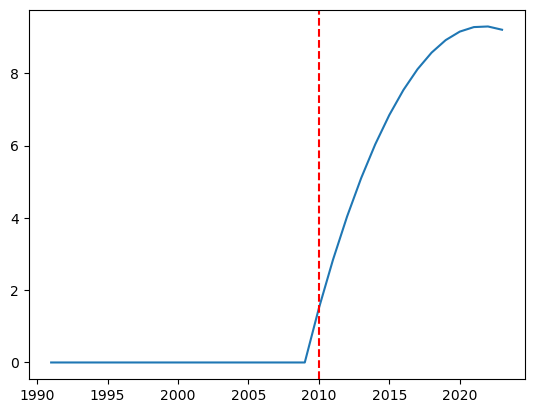

In [264]:
test_x = np.append(np.zeros(19), np.arange(1, 34-19))

test_x = 1.6*test_x - 0.1*test_x**(1.85)

np.savetxt('Exogenous_estimation/wage_gap_data_mock.csv', test_x, delimiter=',')


plt.plot(x, test_x)
plt.axvline(x=2010, color='red', linestyle='--')